<a href="https://colab.research.google.com/github/2303a51355/High-performance-computing/blob/main/parallelllllllllllllllllllllllllllllll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files
uploaded = files.upload()

In [12]:
import cv2
import numpy as np
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt

In [24]:
img = cv2.imread("/content/imageeeeeeeeeeeeeee.jpeg")
if img is None:
    print("Error: Image not loaded. Check file name.")
else:
    print("Image loaded successfully")

Image loaded successfully


In [25]:
start = time.time()
if img is None:
    print("Error: Cannot process an empty image. Please check image loading in previous cell.")
    gray_serial = None # Or handle appropriately, e.g., exit or skip
    serial_time = 0
else:
    gray_serial = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    serial_time = time.time() - start
print("Serial Time:", serial_time)

Serial Time: 0.013246536254882812


In [26]:
def convert_chunk(chunk):
    return cv2.cvtColor(chunk, cv2.COLOR_BGR2GRAY)

if img is None:
    print("Error: Cannot perform parallel processing on an empty image. Please check image loading.")
    gray_parallel = None
    parallel_time = 0
else:
    chunks = np.array_split(img, 2)
    start = time.time()
    with Pool(2) as p:
        result = p.map(convert_chunk, chunks)

    gray_parallel = np.vstack(result)
    parallel_time = time.time() - start

print("Parallel Time:", parallel_time)

Parallel Time: 0.04163002967834473


In [27]:
if gray_serial is not None and gray_parallel is not None:
    difference = np.sum(gray_serial - gray_parallel)

    if difference == 0:
        accuracy = 100
    else:
        accuracy = 100 - (abs(difference) / gray_serial.size)

    print("Accuracy:", accuracy, "%")
else:
    print("Error: Cannot calculate accuracy because serial or parallel processed images are missing.")

Accuracy: 100 %


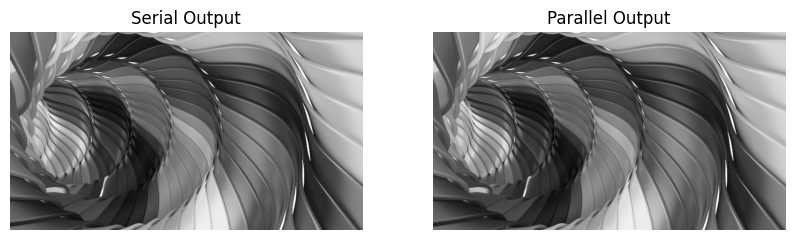

In [28]:
if gray_serial is not None and gray_parallel is not None:
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Serial Output")
    plt.imshow(gray_serial, cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Parallel Output")
    plt.imshow(gray_parallel, cmap='gray')
    plt.axis('off')

    plt.show()
else:
    print("Error: Cannot display images because serial or parallel processed images are missing.")

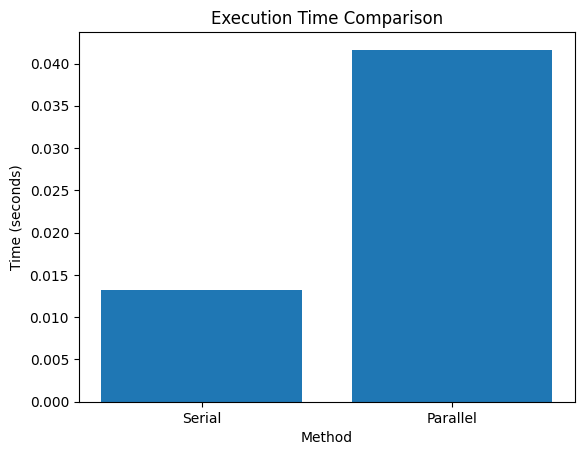

In [29]:
methods = ["Serial", "Parallel"]
times = [serial_time, parallel_time]
plt.figure()
plt.bar(methods, times)
plt.title("Execution Time Comparison")
plt.xlabel("Method")
plt.ylabel("Time (seconds)")
plt.show()

In [30]:
if parallel_time < serial_time:
    print("Parallel is Faster ✅")
else:
    print("Serial is Faster ❌")

Serial is Faster ❌
